In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xg
from sklearn.model_selection import GridSearchCV

In [3]:
train_data = pd.read_csv('fraudTest.csv')
test_data = pd.read_csv('fraudTest.csv')

In [4]:
train_data.head(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
5,5,2020-06-21 12:15:37,30407675418785,fraud_Daugherty LLC,kids_pets,19.55,Danielle,Evans,F,76752 David Lodge Apt. 064,...,42.1939,-76.7361,520,Psychotherapist,1991-10-13,798db04aaceb4febd084f1a7c404da93,1371816937,41.747157,-77.584197,0
6,6,2020-06-21 12:15:44,213180742685905,fraud_Romaguera Ltd,health_fitness,133.93,Kayla,Sutton,F,010 Weaver Land,...,40.5070,-123.9743,1139,"Therapist, occupational",1951-01-15,17003d7ce534440eadb10c4750e020e5,1371816944,41.499458,-124.888729,0
7,7,2020-06-21 12:15:50,3589289942931264,fraud_Reichel LLC,personal_care,10.37,Paula,Estrada,F,350 Stacy Glens,...,43.7557,-97.5936,343,"Development worker, international aid",1972-03-05,8be473af4f05fc6146ea55ace73e7ca2,1371816950,44.495498,-97.728453,0
8,8,2020-06-21 12:16:10,3596357274378601,"fraud_Goyette, Howell and Collier",shopping_pos,4.37,David,Everett,M,4138 David Fall,...,41.0001,-78.2357,3688,Advice worker,1973-05-27,71a1da150d1ce510193d7622e08e784e,1371816970,41.546067,-78.120238,0
9,9,2020-06-21 12:16:11,3546897637165774,fraud_Kilback Group,food_dining,66.54,Kayla,Obrien,F,7921 Robert Port Suite 343,...,31.6591,-96.8094,263,Barrister,1956-05-30,a7915132c7c4240996ba03a47f81e3bd,1371816971,31.782919,-96.366185,0


In [5]:
test_data.head(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
5,5,2020-06-21 12:15:37,30407675418785,fraud_Daugherty LLC,kids_pets,19.55,Danielle,Evans,F,76752 David Lodge Apt. 064,...,42.1939,-76.7361,520,Psychotherapist,1991-10-13,798db04aaceb4febd084f1a7c404da93,1371816937,41.747157,-77.584197,0
6,6,2020-06-21 12:15:44,213180742685905,fraud_Romaguera Ltd,health_fitness,133.93,Kayla,Sutton,F,010 Weaver Land,...,40.5070,-123.9743,1139,"Therapist, occupational",1951-01-15,17003d7ce534440eadb10c4750e020e5,1371816944,41.499458,-124.888729,0
7,7,2020-06-21 12:15:50,3589289942931264,fraud_Reichel LLC,personal_care,10.37,Paula,Estrada,F,350 Stacy Glens,...,43.7557,-97.5936,343,"Development worker, international aid",1972-03-05,8be473af4f05fc6146ea55ace73e7ca2,1371816950,44.495498,-97.728453,0
8,8,2020-06-21 12:16:10,3596357274378601,"fraud_Goyette, Howell and Collier",shopping_pos,4.37,David,Everett,M,4138 David Fall,...,41.0001,-78.2357,3688,Advice worker,1973-05-27,71a1da150d1ce510193d7622e08e784e,1371816970,41.546067,-78.120238,0
9,9,2020-06-21 12:16:11,3546897637165774,fraud_Kilback Group,food_dining,66.54,Kayla,Obrien,F,7921 Robert Port Suite 343,...,31.6591,-96.8094,263,Barrister,1956-05-30,a7915132c7c4240996ba03a47f81e3bd,1371816971,31.782919,-96.366185,0


In [6]:
train_data.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
train_data.head(10)

,id,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
5,5,2020-06-21 12:15:37,30407675418785,fraud_Daugherty LLC,kids_pets,19.55,Danielle,Evans,F,76752 David Lodge Apt. 064,...,42.1939,-76.7361,520,Psychotherapist,1991-10-13,798db04aaceb4febd084f1a7c404da93,1371816937,41.747157,-77.584197,0
6,6,2020-06-21 12:15:44,213180742685905,fraud_Romaguera Ltd,health_fitness,133.93,Kayla,Sutton,F,010 Weaver Land,...,40.5070,-123.9743,1139,"Therapist, occupational",1951-01-15,17003d7ce534440eadb10c4750e020e5,1371816944,41.499458,-124.888729,0
7,7,2020-06-21 12:15:50,3589289942931264,fraud_Reichel LLC,personal_care,10.37,Paula,Estrada,F,350 Stacy Glens,...,43.7557,-97.5936,343,"Development worker, international aid",1972-03-05,8be473af4f05fc6146ea55ace73e7ca2,1371816950,44.495498,-97.728453,0
8,8,2020-06-21 12:16:10,3596357274378601,"fraud_Goyette, Howell and Collier",shopping_pos,4.37,David,Everett,M,4138 David Fall,...,41.0001,-78.2357,3688,Advice worker,1973-05-27,71a1da150d1ce510193d7622e08e784e,1371816970,41.546067,-78.120238,0
9,9,2020-06-21 12:16:11,3546897637165774,fraud_Kilback Group,food_dining,66.54,Kayla,Obrien,F,7921 Robert Port Suite 343,...,31.6591,-96.8094,263,Barrister,1956-05-30,a7915132c7c4240996ba03a47f81e3bd,1371816971,31.782919,-96.366185,0


In [7]:
test_data.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
test_data.head(10)

,id,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
5,5,2020-06-21 12:15:37,30407675418785,fraud_Daugherty LLC,kids_pets,19.55,Danielle,Evans,F,76752 David Lodge Apt. 064,...,42.1939,-76.7361,520,Psychotherapist,1991-10-13,798db04aaceb4febd084f1a7c404da93,1371816937,41.747157,-77.584197,0
6,6,2020-06-21 12:15:44,213180742685905,fraud_Romaguera Ltd,health_fitness,133.93,Kayla,Sutton,F,010 Weaver Land,...,40.5070,-123.9743,1139,"Therapist, occupational",1951-01-15,17003d7ce534440eadb10c4750e020e5,1371816944,41.499458,-124.888729,0
7,7,2020-06-21 12:15:50,3589289942931264,fraud_Reichel LLC,personal_care,10.37,Paula,Estrada,F,350 Stacy Glens,...,43.7557,-97.5936,343,"Development worker, international aid",1972-03-05,8be473af4f05fc6146ea55ace73e7ca2,1371816950,44.495498,-97.728453,0
8,8,2020-06-21 12:16:10,3596357274378601,"fraud_Goyette, Howell and Collier",shopping_pos,4.37,David,Everett,M,4138 David Fall,...,41.0001,-78.2357,3688,Advice worker,1973-05-27,71a1da150d1ce510193d7622e08e784e,1371816970,41.546067,-78.120238,0
9,9,2020-06-21 12:16:11,3546897637165774,fraud_Kilback Group,food_dining,66.54,Kayla,Obrien,F,7921 Robert Port Suite 343,...,31.6591,-96.8094,263,Barrister,1956-05-30,a7915132c7c4240996ba03a47f81e3bd,1371816971,31.782919,-96.366185,0


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [9]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [10]:
train_data.isnull().sum()

id                       0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [11]:
test_data.isnull().sum()

id                       0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [12]:
train_data.duplicated().sum()

np.int64(0)

In [13]:
test_data.duplicated().sum()

np.int64(0)

In [14]:
for col in train_data.select_dtypes(exclude=['object']).columns:
    print(f'Column {col} has {train_data[col].nunique()} unique values')

Column id has 555719 unique values
Column cc_num has 924 unique values
Column amt has 37256 unique values
Column zip has 912 unique values
Column lat has 910 unique values
Column long has 910 unique values
Column city_pop has 835 unique values
Column unix_time has 544760 unique values
Column merch_lat has 546490 unique values
Column merch_long has 551770 unique values
Column is_fraud has 2 unique values


In [15]:
for col in test_data.select_dtypes(exclude=['object']).columns:
    print(f'Column {col} has {test_data[col].nunique()} unique values')

Column id has 555719 unique values
Column cc_num has 924 unique values
Column amt has 37256 unique values
Column zip has 912 unique values
Column lat has 910 unique values
Column long has 910 unique values
Column city_pop has 835 unique values
Column unix_time has 544760 unique values
Column merch_lat has 546490 unique values
Column merch_long has 551770 unique values
Column is_fraud has 2 unique values


In [16]:
train_data['trans_date_trans_time'] = pd.to_datetime(train_data['trans_date_trans_time'])
train_data['dob'] = pd.to_datetime(train_data['dob'])
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     555719 non-null  int64         
 1   trans_date_trans_time  555719 non-null  datetime64[ns]
 2   cc_num                 555719 non-null  int64         
 3   merchant               555719 non-null  object        
 4   category               555719 non-null  object        
 5   amt                    555719 non-null  float64       
 6   first                  555719 non-null  object        
 7   last                   555719 non-null  object        
 8   gender                 555719 non-null  object        
 9   street                 555719 non-null  object        
 10  city                   555719 non-null  object        
 11  state                  555719 non-null  object        
 12  zip                    555719 non-null  int6

In [17]:
test_data['trans_date_trans_time'] = pd.to_datetime(train_data['trans_date_trans_time'])
test_data['dob'] = pd.to_datetime(train_data['dob'])
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     555719 non-null  int64         
 1   trans_date_trans_time  555719 non-null  datetime64[ns]
 2   cc_num                 555719 non-null  int64         
 3   merchant               555719 non-null  object        
 4   category               555719 non-null  object        
 5   amt                    555719 non-null  float64       
 6   first                  555719 non-null  object        
 7   last                   555719 non-null  object        
 8   gender                 555719 non-null  object        
 9   street                 555719 non-null  object        
 10  city                   555719 non-null  object        
 11  state                  555719 non-null  object        
 12  zip                    555719 non-null  int6

In [18]:
train_data['is_fraud'].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [19]:
test_data['is_fraud'].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [20]:
train_data['category'].value_counts()

category
gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x24282234980>,
 [Text(1.0446178655155618, 0.34463533632770715, 'gas_transport'),
  Text(0.6537001615130746, 0.8846898319963784, 'grocery_pos'),
  Text(0.04767183180148798, 1.0989665128895834, 'home'),
  Text(-0.5599204088735377, 0.9468311020065251, 'shopping_pos'),
  Text(-0.9756904532345682, 0.5079647029734675, 'kids_pets'),
  Text(-1.0994562816662732, -0.034581565964725273, 'shopping_net'),
  Text(-0.9683081117962197, -0.5218997994152133, 'entertainment'),
  Text(-0.6457574715678701, -0.8905039516556181, 'personal_care'),
  Text(-0.2002856835082207, -1.081612520721559, 'food_dining'),
  Text(0.2681097451006755, -1.0668257423694139, 'health_fitness'),
  Text(0.6648254180450732, -0.8763601791051404, 'misc_pos'),
  Text(0.9251189807672051, -0.5951091256435644, 'misc_net'),
  Text(1.048534190197635, -0.33252977609018675, 'grocery_net'),
  Text(1.0946526331462572, -0.10833103316208992, 'travel')],
 [Text(0.5697915630084882, 0.18798291072420387, '10.1%'),
  

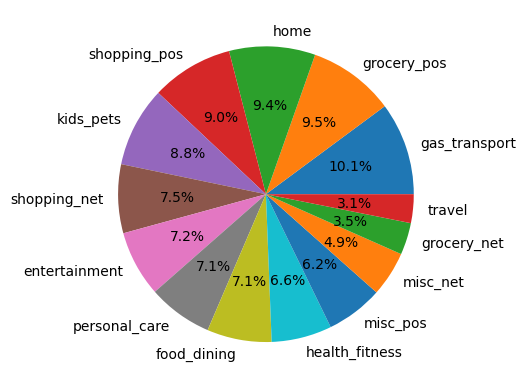

In [21]:
plot.pie(train_data['category'].value_counts(), labels=train_data['category'].value_counts().index, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x2428230e5d0>,
 [Text(1.0446178655155618, 0.34463533632770715, 'gas_transport'),
  Text(0.6537001615130746, 0.8846898319963784, 'grocery_pos'),
  Text(0.04767183180148798, 1.0989665128895834, 'home'),
  Text(-0.5599204088735377, 0.9468311020065251, 'shopping_pos'),
  Text(-0.9756904532345682, 0.5079647029734675, 'kids_pets'),
  Text(-1.0994562816662732, -0.034581565964725273, 'shopping_net'),
  Text(-0.9683081117962197, -0.5218997994152133, 'entertainment'),
  Text(-0.6457574715678701, -0.8905039516556181, 'personal_care'),
  Text(-0.2002856835082207, -1.081612520721559, 'food_dining'),
  Text(0.2681097451006755, -1.0668257423694139, 'health_fitness'),
  Text(0.6648254180450732, -0.8763601791051404, 'misc_pos'),
  Text(0.9251189807672051, -0.5951091256435644, 'misc_net'),
  Text(1.048534190197635, -0.33252977609018675, 'grocery_net'),
  Text(1.0946526331462572, -0.10833103316208992, 'travel')],
 [Text(0.5697915630084882, 0.18798291072420387, '10.1%'),
  

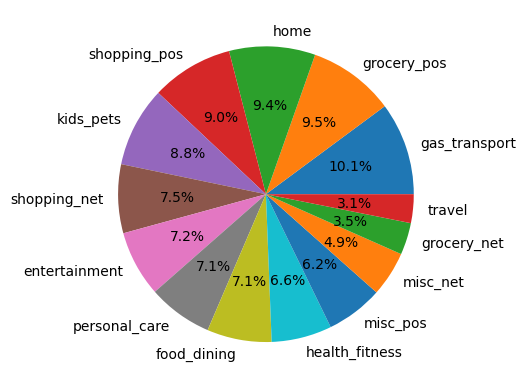

In [22]:
plot.pie(test_data['category'].value_counts(), labels=test_data['category'].value_counts().index, autopct='%1.1f%%')

In [23]:
train_data['amt'].describe()

count    555719.000000
mean         69.392810
std         156.745941
min           1.000000
25%           9.630000
50%          47.290000
75%          83.010000
max       22768.110000
Name: amt, dtype: float64

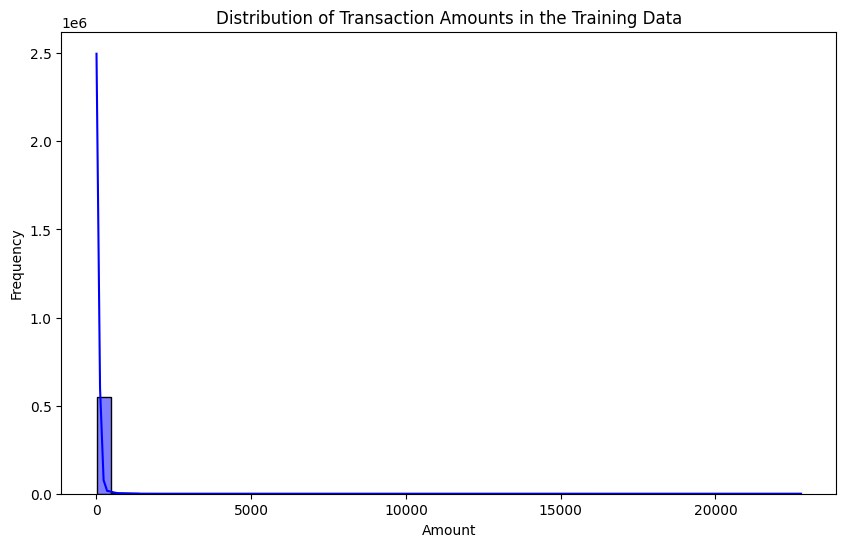

In [24]:
plot.figure(figsize=(10, 6))
sns.histplot(train_data['amt'], kde=True, color='blue', bins=50)
plot.title('Distribution of Transaction Amounts in the Training Data')
plot.xlabel('Amount')
plot.ylabel('Frequency')
plot.show()

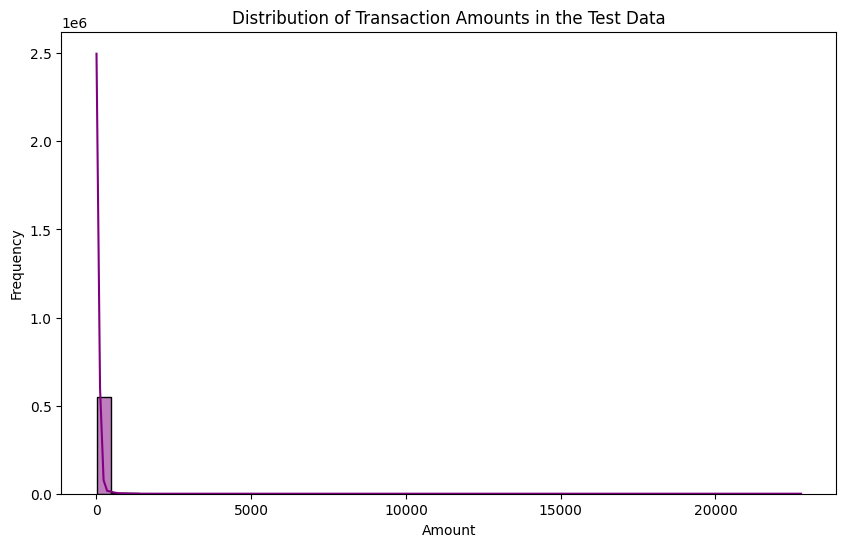

In [25]:
plot.figure(figsize=(10, 6))
sns.histplot(test_data['amt'], kde=True, color='purple', bins=50)
plot.title('Distribution of Transaction Amounts in the Test Data')
plot.xlabel('Amount')
plot.ylabel('Frequency')
plot.show()

In [26]:
train_data['gender'].value_counts()

gender
F    304886
M    250833
Name: count, dtype: int64

In [27]:
test_data['gender'].value_counts()

gender
F    304886
M    250833
Name: count, dtype: int64

In [28]:
train_data['trans_month'] = train_data['trans_date_trans_time'].dt.month
train_data['trans_day'] = train_data['trans_date_trans_time'].dt.day_name()
train_data['trans_hour'] = train_data['trans_date_trans_time'].dt.hour
train_data.head()

,id,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_month,trans_day,trans_hour
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,6,Sunday,12
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,6,Sunday,12
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,6,Sunday,12
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,6,Sunday,12
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,6,Sunday,12


In [29]:
for col in train_data[['trans_month', 'trans_day', 'trans_hour']]:
    print(f'Column {col} has {train_data[col].nunique()} unique values')
    print(train_data[col].value_counts())
    print('\n')

Column trans_month has 7 unique values
trans_month
12    139538
8      88759
7      85848
11     72635
9      69533
10     69348
6      30058
Name: count, dtype: int64


Column trans_day has 7 unique values
trans_day
Monday       115136
Tuesday      110113
Sunday        93098
Friday        62806
Saturday      62270
Thursday      59456
Wednesday     52840
Name: count, dtype: int64


Column trans_hour has 24 unique values
trans_hour
23    28798
16    28563
22    28388
21    28205
14    28204
13    28178
17    28064
15    28048
12    28037
18    28001
20    27983
19    27925
1     18461
3     18199
0     18153
2     18140
6     18106
7     18098
11    18088
4     18075
10    18049
9     18046
8     17993
5     17917
Name: count, dtype: int64




In [30]:
test_data['trans_month'] = test_data['trans_date_trans_time'].dt.month
test_data['trans_day'] = test_data['trans_date_trans_time'].dt.day_name()
test_data['trans_hour'] = test_data['trans_date_trans_time'].dt.hour

for col in test_data[['trans_month', 'trans_day', 'trans_hour']]:
    print(f'Column {col} has {test_data[col].nunique()} unique values')
    print(test_data[col].value_counts())
    print('\n')

Column trans_month has 7 unique values
trans_month
12    139538
8      88759
7      85848
11     72635
9      69533
10     69348
6      30058
Name: count, dtype: int64


Column trans_day has 7 unique values
trans_day
Monday       115136
Tuesday      110113
Sunday        93098
Friday        62806
Saturday      62270
Thursday      59456
Wednesday     52840
Name: count, dtype: int64


Column trans_hour has 24 unique values
trans_hour
23    28798
16    28563
22    28388
21    28205
14    28204
13    28178
17    28064
15    28048
12    28037
18    28001
20    27983
19    27925
1     18461
3     18199
0     18153
2     18140
6     18106
7     18098
11    18088
4     18075
10    18049
9     18046
8     17993
5     17917
Name: count, dtype: int64




In [31]:
train_data['is_weekend'] = train_data['trans_day'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)
train_data['is_weekend'].value_counts()

is_weekend
0    400351
1    155368
Name: count, dtype: int64

In [32]:
test_data['is_weekend'] = test_data['trans_day'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)
test_data['is_weekend'].value_counts()

is_weekend
0    400351
1    155368
Name: count, dtype: int64

In [33]:
def period_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'midnght'

train_data['period_of_day'] = train_data['trans_hour'].apply(period_of_day)
train_data['period_of_day'].value_counts()

period_of_day
evening      169300
afternoon    169094
midnght      108945
morning      108380
Name: count, dtype: int64

In [34]:
test_data['period_of_day'] = test_data['trans_hour'].apply(period_of_day)
test_data['period_of_day'].value_counts()

period_of_day
evening      169300
afternoon    169094
midnght      108945
morning      108380
Name: count, dtype: int64

In [35]:
ref_date = pd.to_datetime('2021-01-01')
train_data['age'] = (ref_date - train_data['dob']).dt.days // 365
train_data['age'].value_counts().sort_index()

age
15     963
16    3471
17    1858
18      12
19    2479
      ... 
91    2571
92    1721
93    1956
94    2720
96     199
Name: count, Length: 81, dtype: int64

In [36]:
test_data['age'] = (ref_date - test_data['dob']).dt.days // 365
test_data['age'].value_counts().sort_index()

age
15     963
16    3471
17    1858
18      12
19    2479
      ... 
91    2571
92    1721
93    1956
94    2720
96     199
Name: count, Length: 81, dtype: int64

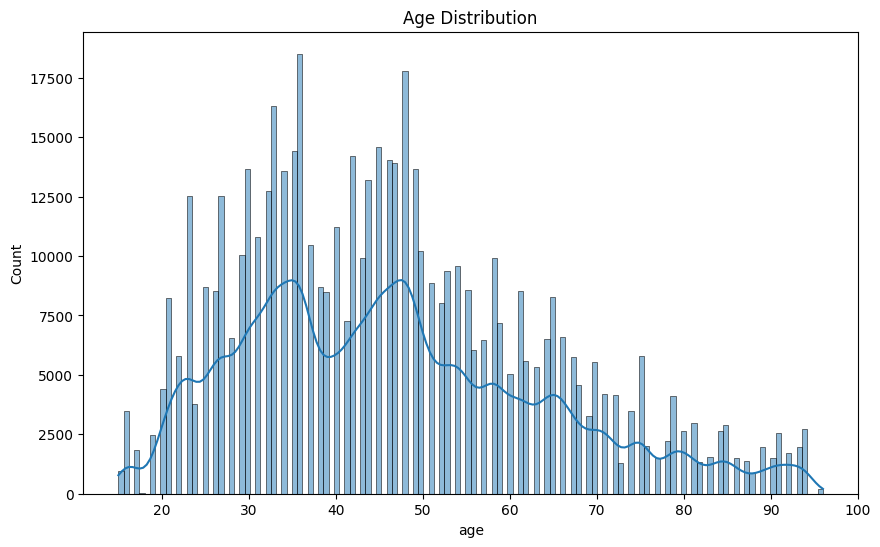

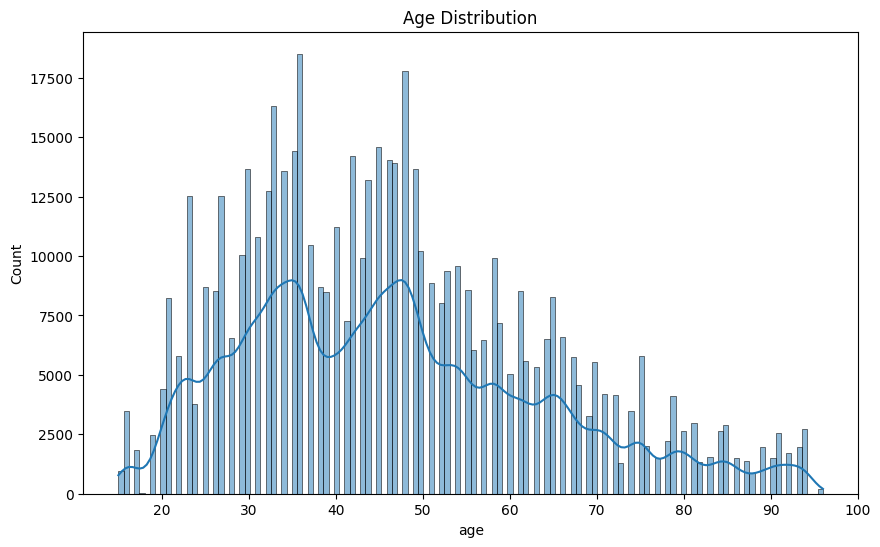

In [37]:
for ages in [train_data['age'], test_data['age']]:
    plot.figure(figsize=(10, 6))
    sns.histplot(ages, kde=True)
    plot.title('Age Distribution')
    plot.show()

In [38]:
def age_group(age):
    if 0 <= age < 18:
        return 'minor'
    elif 18 <= age < 30:
        return 'young adult'
    elif 30 <= age < 50:
        return 'adult'
    else:
        return 'senior'

train_data['age_group'] = train_data['age'].apply(age_group)
test_data['age_group'] = test_data['age'].apply(age_group)

In [39]:
train_data['state'].nunique()
train_data['state'].value_counts().sort_index()

state
AK      843
AL    17532
AR    13484
AZ     4592
CA    24135
CO     5886
CT     3277
DC     1517
FL    18104
GA    11277
HI     1090
IA    11819
ID     2490
IL    18960
IN    11959
KS     9943
KY    12506
LA     8988
MA     5186
MD    11152
ME     6928
MI    19671
MN    13719
MO    16501
MS     8833
MT     5052
NC    12868
ND     6397
NE    10257
NH     3449
NJ    10528
NM     7020
NV     2451
NY    35918
OH    20147
OK    11379
OR     7811
PA    34326
RI      195
SC    12541
SD     5250
TN     7359
TX    40393
UT     4658
VA    12506
VT     5044
WA     8116
WI    12370
WV    10838
WY     8454
Name: count, dtype: int64

In [40]:
train_data['state'].nunique()
train_data['state'].value_counts().sort_index()

state
AK      843
AL    17532
AR    13484
AZ     4592
CA    24135
CO     5886
CT     3277
DC     1517
FL    18104
GA    11277
HI     1090
IA    11819
ID     2490
IL    18960
IN    11959
KS     9943
KY    12506
LA     8988
MA     5186
MD    11152
ME     6928
MI    19671
MN    13719
MO    16501
MS     8833
MT     5052
NC    12868
ND     6397
NE    10257
NH     3449
NJ    10528
NM     7020
NV     2451
NY    35918
OH    20147
OK    11379
OR     7811
PA    34326
RI      195
SC    12541
SD     5250
TN     7359
TX    40393
UT     4658
VA    12506
VT     5044
WA     8116
WI    12370
WV    10838
WY     8454
Name: count, dtype: int64

In [41]:
def regionize(state):
    if state in ['IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD']:
        return 'Midwest'
    elif state in ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA']:
        return 'Northeast'
    elif state in ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'DC', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX']:
        return 'South'
    else:
        return 'West'

In [42]:
train_data['state_region'] = train_data['state'].apply(regionize)
train_data['state_region'].value_counts()


state_region
South        211277
West         165705
Northeast    104851
Midwest       73886
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x242843b82d0>,
 [Text(0.40433695156986327, 1.0229915100308458, 'South'),
  Text(-1.081440723465713, -0.20121123634120205, 'West'),
  Text(0.1564022060351148, -1.0888242970963449, 'Northeast'),
  Text(1.0054299506873516, -0.4462181240837599, 'Midwest')],
 [Text(0.22054742812901632, 0.5579953691077341, '38.0%'),
  Text(-0.5898767582540253, -0.10975158345883747, '29.8%'),
  Text(0.08531029420097169, -0.5939041620525517, '18.9%'),
  Text(0.5484163367385554, -0.2433917040456872, '13.3%')])

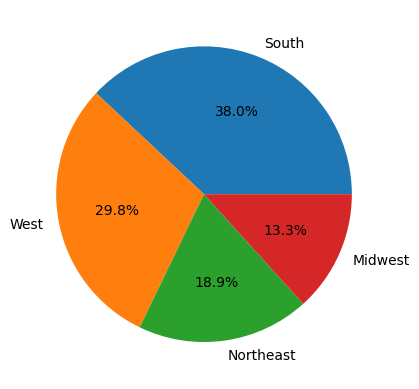

In [43]:
plot.pie(train_data['state_region'].value_counts(), labels=train_data['state_region'].value_counts().index, autopct='%1.1f%%')

In [44]:
test_data['state_region'] = test_data['state'].apply(regionize)
test_data['state_region'].value_counts()

state_region
South        211277
West         165705
Northeast    104851
Midwest       73886
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x24284400550>,
 [Text(0.40433695156986327, 1.0229915100308458, 'South'),
  Text(-1.081440723465713, -0.20121123634120205, 'West'),
  Text(0.1564022060351148, -1.0888242970963449, 'Northeast'),
  Text(1.0054299506873516, -0.4462181240837599, 'Midwest')],
 [Text(0.22054742812901632, 0.5579953691077341, '38.0%'),
  Text(-0.5898767582540253, -0.10975158345883747, '29.8%'),
  Text(0.08531029420097169, -0.5939041620525517, '18.9%'),
  Text(0.5484163367385554, -0.2433917040456872, '13.3%')])

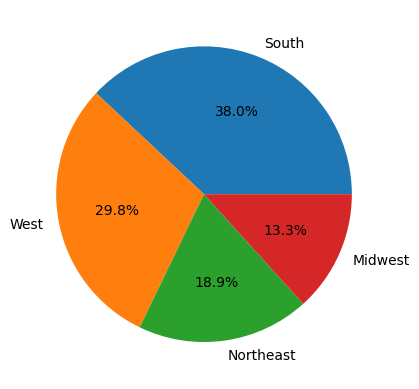

In [45]:
plot.pie(test_data['state_region'].value_counts(), labels=test_data['state_region'].value_counts().index, autopct='%1.1f%%')

In [46]:
train_data['city_pop'].describe()

count    5.557190e+05
mean     8.822189e+04
std      3.003909e+05
min      2.300000e+01
25%      7.410000e+02
50%      2.408000e+03
75%      1.968500e+04
max      2.906700e+06
Name: city_pop, dtype: float64

In [47]:
city_pop_bins = [0, 10000, 50000, 100000, 500000, 1000000, np.inf]
city_pop_labels = ['<10k', '10k-50k', '50k-100k', '100k-500k', '500k-1M', '1M+']

In [48]:
train_data['city_pop_group'] = pd.cut(train_data['city_pop'], bins=city_pop_bins, labels=city_pop_labels)
train_data['city_pop_group'].value_counts()

city_pop_group
<10k         389959
10k-50k       62243
100k-500k     47888
50k-100k      27601
1M+           14046
500k-1M       13982
Name: count, dtype: int64

C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\3746491372.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='city_pop_group', data=train_data, order=city_pop_labels, palette='flare_r')


<Axes: xlabel='city_pop_group', ylabel='count'>

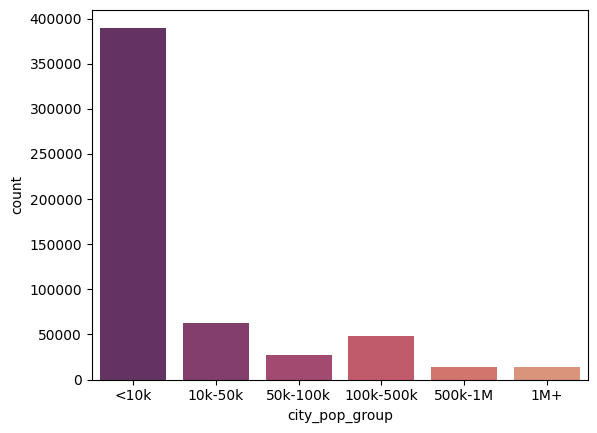

In [49]:
sns.countplot(x='city_pop_group', data=train_data, order=city_pop_labels, palette='flare_r')

C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\1571550109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='city_pop_group', data=test_data, order=city_pop_labels, palette='flare_r')


<Axes: xlabel='city_pop_group', ylabel='count'>

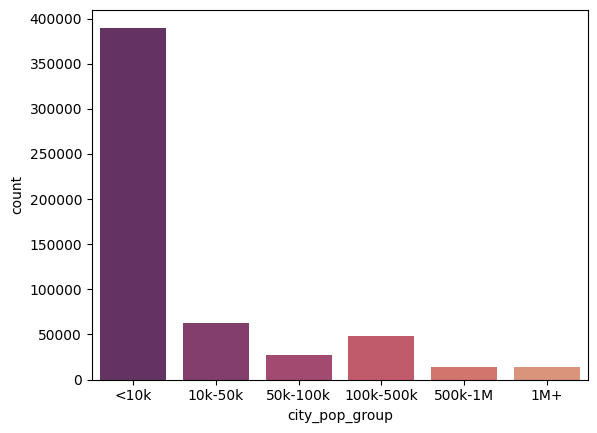

In [50]:
test_data['city_pop_group'] = pd.cut(test_data['city_pop'], bins=city_pop_bins, labels=city_pop_labels)
sns.countplot(x='city_pop_group', data=test_data, order=city_pop_labels, palette='flare_r')

In [51]:
fraud_df = train_data[train_data['is_fraud'] == 1]
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2145 entries, 1685 to 517571
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     2145 non-null   int64         
 1   trans_date_trans_time  2145 non-null   datetime64[ns]
 2   cc_num                 2145 non-null   int64         
 3   merchant               2145 non-null   object        
 4   category               2145 non-null   object        
 5   amt                    2145 non-null   float64       
 6   first                  2145 non-null   object        
 7   last                   2145 non-null   object        
 8   gender                 2145 non-null   object        
 9   street                 2145 non-null   object        
 10  city                   2145 non-null   object        
 11  state                  2145 non-null   object        
 12  zip                    2145 non-null   int64         
 13  lat

([<matplotlib.patches.Wedge at 0x242973320d0>,
 [Text(0.8115037169603181, 0.742604684444953, 'shopping_net'),
  Text(-0.6406846236643859, 0.8941606192402036, 'grocery_pos'),
  Text(-1.0872639732067508, -0.16690432159374993, 'misc_net'),
  Text(-0.7215633783000651, -0.8302688065296668, 'shopping_pos'),
  Text(-0.19471395189687454, -1.0826294273373054, 'gas_transport'),
  Text(0.16770104898572738, -1.087141369909676, 'misc_pos'),
  Text(0.38855850402439734, -1.0290880860987182, 'personal_care'),
  Text(0.5858686942061485, -0.930998320701591, 'home'),
  Text(0.7538237486300269, -0.8010928510487247, 'kids_pets'),
  Text(0.8861158589618338, -0.6517658202884925, 'entertainment'),
  Text(0.9813838828527424, -0.4968759145670831, 'food_dining'),
  Text(1.0464108670911398, -0.33915232158068587, 'health_fitness'),
  Text(1.082771688823426, -0.1939212981662044, 'grocery_net'),
  Text(1.0981128598527974, -0.06440611015975793, 'travel')],
 [Text(0.44263839106926434, 0.4050571006063379, '23.6%'),
  T

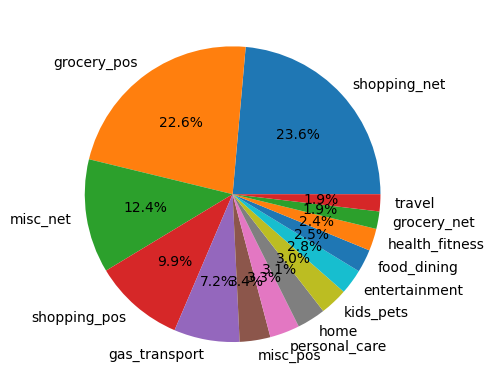

In [52]:
plot.pie(fraud_df['category'].value_counts(), labels=fraud_df['category'].value_counts().index, autopct='%1.1f%%')

In [53]:
fraud_df['amt'].describe()

count    2145.000000
mean      528.356494
std       392.747594
min         1.780000
25%       214.510000
50%       371.940000
75%       907.770000
max      1320.920000
Name: amt, dtype: float64

Text(0, 0.5, 'Frequency')

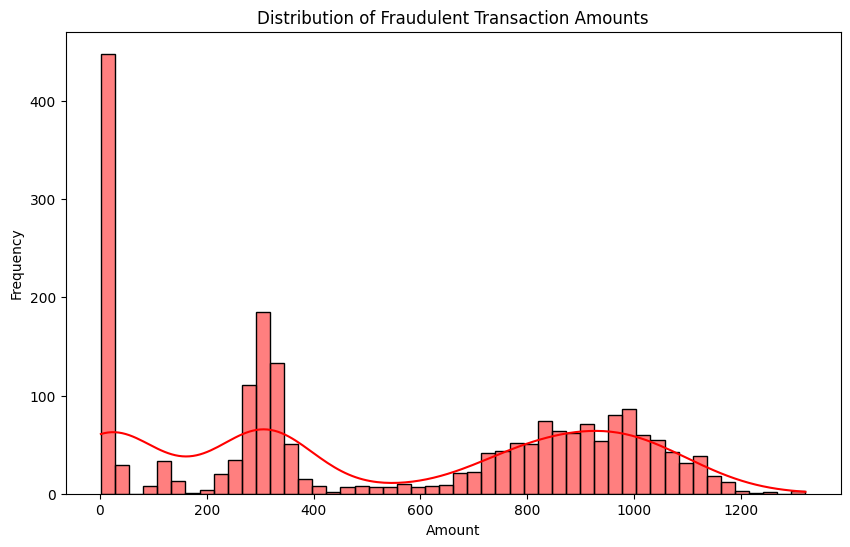

In [54]:
plot.figure(figsize=(10, 6))
fig_amt = sns.histplot(fraud_df['amt'], kde=True, color='red', bins=50)
plot.title('Distribution of Fraudulent Transaction Amounts')
plot.xlabel('Amount')
plot.ylabel('Frequency')


C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\2359970319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig_gender = sns.countplot(x='gender', data=fraud_df, palette='tab10')


Text(0, 0.5, 'Count')

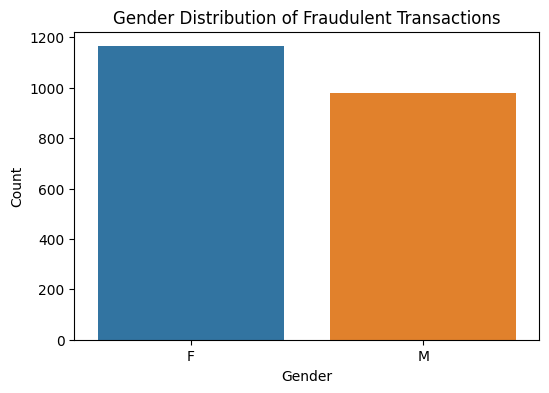

In [55]:
plot.figure(figsize=(6, 4))
fig_gender = sns.countplot(x='gender', data=fraud_df, palette='tab10')
plot.title('Gender Distribution of Fraudulent Transactions')
plot.xlabel('Gender')
plot.ylabel('Count')

C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\1796678078.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig_month = sns.countplot(x='trans_month', data=fraud_df, palette='viridis')


Text(0, 0.5, 'Count')

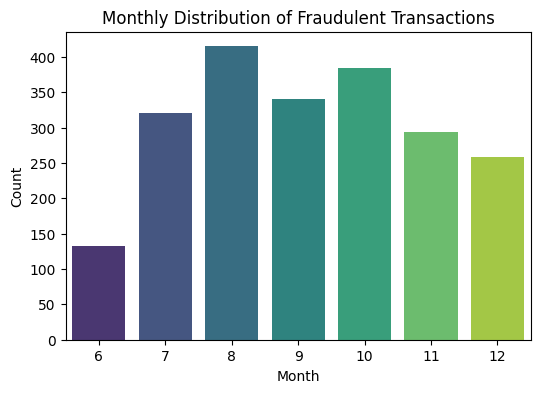

In [56]:
plot.figure(figsize=(6, 4))
fig_month = sns.countplot(x='trans_month', data=fraud_df, palette='viridis')
plot.title('Monthly Distribution of Fraudulent Transactions')
plot.xlabel('Month')
plot.ylabel('Count')


C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\3405616133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig_time = sns.countplot(x='period_of_day', data=fraud_df, palette='rocket_r', order=['morning', 'afternoon', 'evening', 'midnght'])


Text(0, 0.5, 'Count')

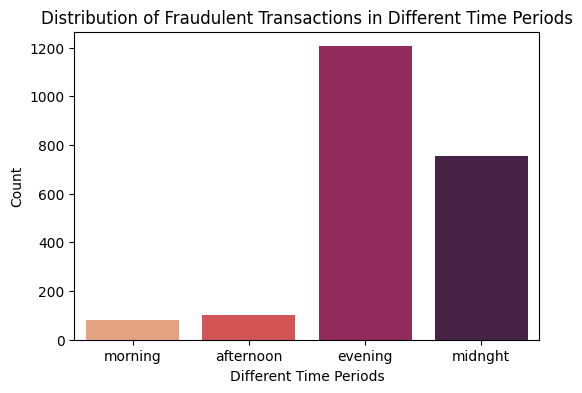

In [57]:
plot.figure(figsize=(6, 4))
fig_time = sns.countplot(x='period_of_day', data=fraud_df, palette='rocket_r', order=['morning', 'afternoon', 'evening', 'midnght'])
plot.title('Distribution of Fraudulent Transactions in Different Time Periods')
plot.xlabel('Different Time Periods')
plot.ylabel('Count')

C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\3874576493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig_age = sns.countplot(x='age_group', data=fraud_df, palette='crest', order=['minor', 'young adult', 'adult', 'senior'])


Text(0, 0.5, 'Count')

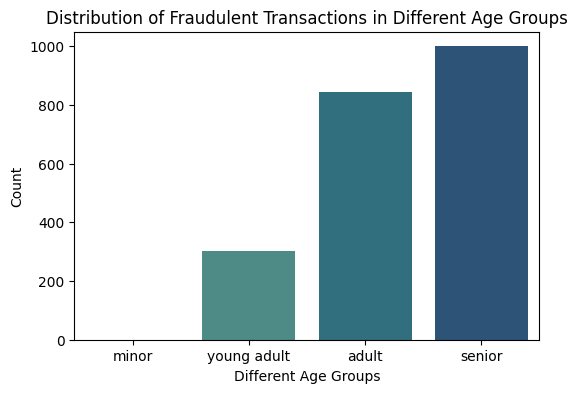

In [58]:
plot.figure(figsize=(6, 4))
fig_age = sns.countplot(x='age_group', data=fraud_df, palette='crest', order=['minor', 'young adult', 'adult', 'senior'])
plot.title('Distribution of Fraudulent Transactions in Different Age Groups')
plot.xlabel('Different Age Groups')
plot.ylabel('Count')

C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\1099980059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud_df['state_region'] = fraud_df['state'].apply(regionize)


([<matplotlib.patches.Wedge at 0x2428423bc50>,
 [Text(0.48606588109829263, 0.9867826301836391, 'South'),
  Text(-1.0999811198123588, -0.006444847271226041, 'West'),
  Text(-0.023358817131695644, -1.0997519564257243, 'Northeast'),
  Text(0.9732519951364409, -0.5126212578141267, 'Midwest')],
 [Text(0.2651268442354323, 0.5382450710092577, '35.4%'),
  Text(-0.599989701715832, -0.003515371238850567, '29.3%'),
  Text(-0.012741172980924897, -0.5998647035049405, '19.8%'),
  Text(0.5308647246198768, -0.27961159517134176, '15.4%')])

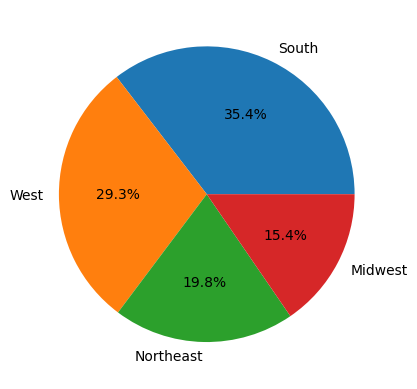

In [59]:
fraud_df['state_region'] = fraud_df['state'].apply(regionize)
plot.pie(fraud_df['state_region'].value_counts(), labels=fraud_df['state_region'].value_counts().index, autopct='%1.1f%%')

C:\Users\nks97\AppData\Local\Temp\ipykernel_7256\3129360646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig_city_pop = sns.countplot(x='city_pop_group', data=fraud_df, order=city_pop_labels, palette='flare_r')


Text(0, 0.5, 'Count')

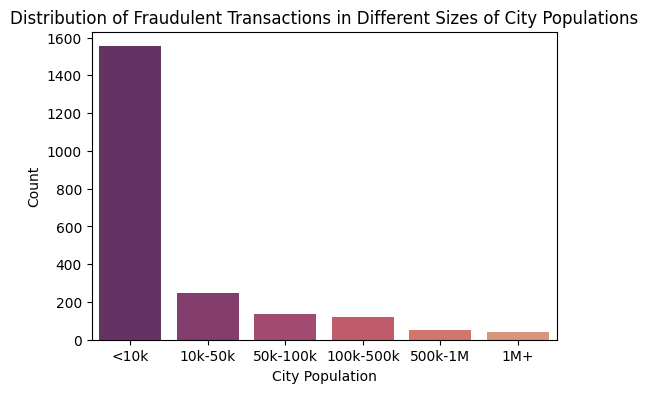

In [60]:
plot.figure(figsize=(6, 4))
fig_city_pop = sns.countplot(x='city_pop_group', data=fraud_df, order=city_pop_labels, palette='flare_r')
plot.title('Distribution of Fraudulent Transactions in Different Sizes of City Populations')
plot.xlabel('City Population')
plot.ylabel('Count')


In [61]:
train_numeric = train_data.select_dtypes(include=[np.number])
train_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           555719 non-null  int64  
 1   cc_num       555719 non-null  int64  
 2   amt          555719 non-null  float64
 3   zip          555719 non-null  int64  
 4   lat          555719 non-null  float64
 5   long         555719 non-null  float64
 6   city_pop     555719 non-null  int64  
 7   unix_time    555719 non-null  int64  
 8   merch_lat    555719 non-null  float64
 9   merch_long   555719 non-null  float64
 10  is_fraud     555719 non-null  int64  
 11  trans_month  555719 non-null  int32  
 12  trans_hour   555719 non-null  int32  
 13  is_weekend   555719 non-null  int64  
 14  age          555719 non-null  int64  
dtypes: float64(5), int32(2), int64(8)
memory usage: 59.4 MB


Text(0.5, 1.0, 'Correation Matrix of Numeric Features')

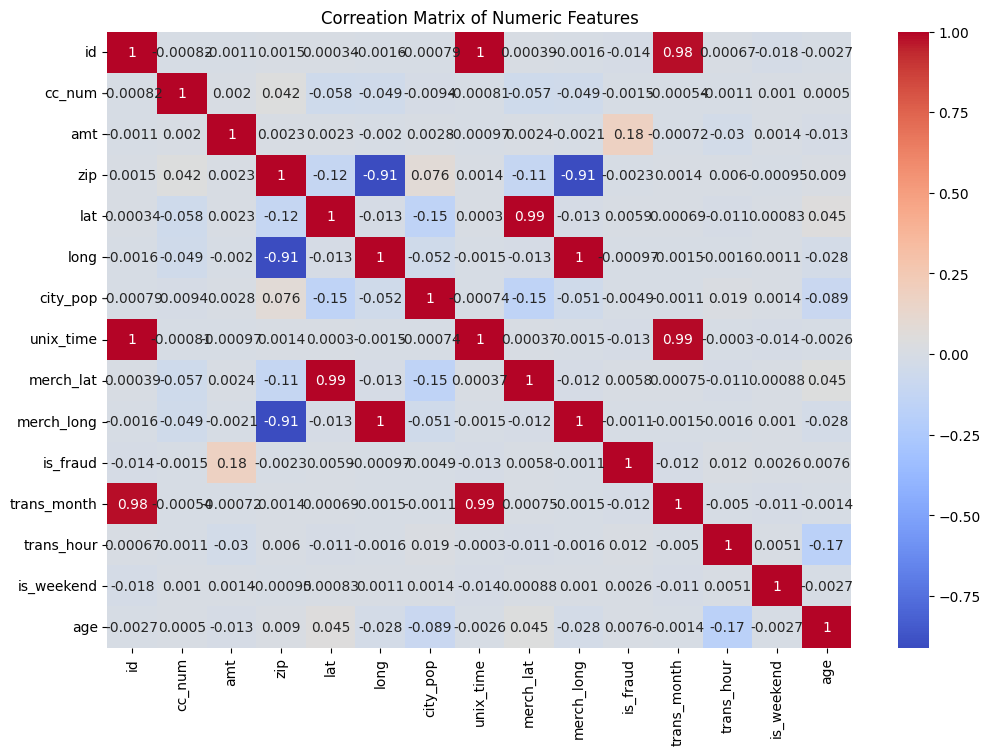

In [62]:
plot.figure(figsize=(12,8))
fig_corr = sns.heatmap(train_numeric.corr(), annot=True, cmap='coolwarm')
plot.title('Correation Matrix of Numeric Features')

In [63]:
train_non_num = train_data.select_dtypes(exclude=[np.number])
train_non_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  555719 non-null  datetime64[ns]
 1   merchant               555719 non-null  object        
 2   category               555719 non-null  object        
 3   first                  555719 non-null  object        
 4   last                   555719 non-null  object        
 5   gender                 555719 non-null  object        
 6   street                 555719 non-null  object        
 7   city                   555719 non-null  object        
 8   state                  555719 non-null  object        
 9   job                    555719 non-null  object        
 10  dob                    555719 non-null  datetime64[ns]
 11  trans_num              555719 non-null  object        
 12  trans_day              555719 non-null  obje

In [64]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     555719 non-null  int64         
 1   trans_date_trans_time  555719 non-null  datetime64[ns]
 2   cc_num                 555719 non-null  int64         
 3   merchant               555719 non-null  object        
 4   category               555719 non-null  object        
 5   amt                    555719 non-null  float64       
 6   first                  555719 non-null  object        
 7   last                   555719 non-null  object        
 8   gender                 555719 non-null  object        
 9   street                 555719 non-null  object        
 10  city                   555719 non-null  object        
 11  state                  555719 non-null  object        
 12  zip                    555719 non-null  int6

In [65]:
drop_cols = ['id', 'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop_group', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'period_of_day', 'age_group', 'state_region', 'trans_day']
train_data_modeling = train_data.drop(drop_cols, axis=1)
train_data_modeling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   category     555719 non-null  object 
 1   amt          555719 non-null  float64
 2   gender       555719 non-null  object 
 3   city_pop     555719 non-null  int64  
 4   is_fraud     555719 non-null  int64  
 5   trans_month  555719 non-null  int32  
 6   trans_hour   555719 non-null  int32  
 7   is_weekend   555719 non-null  int64  
 8   age          555719 non-null  int64  
dtypes: float64(1), int32(2), int64(4), object(2)
memory usage: 33.9+ MB


In [66]:
test_data_modeling = test_data.drop(drop_cols, axis=1)
test_data_modeling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   category     555719 non-null  object 
 1   amt          555719 non-null  float64
 2   gender       555719 non-null  object 
 3   city_pop     555719 non-null  int64  
 4   is_fraud     555719 non-null  int64  
 5   trans_month  555719 non-null  int32  
 6   trans_hour   555719 non-null  int32  
 7   is_weekend   555719 non-null  int64  
 8   age          555719 non-null  int64  
dtypes: float64(1), int32(2), int64(4), object(2)
memory usage: 33.9+ MB


In [67]:
train_data_modeling['gender'] = train_data_modeling['gender'].apply(lambda x: 1 if x == 'M' else 0) 
# Male is 1, female is 0
train_data_modeling.head()

,category,amt,gender,city_pop,is_fraud,trans_month,trans_hour,is_weekend,age
0,personal_care,2.86,1,333497,0,6,12,1,52
1,personal_care,29.84,0,302,0,6,12,1,30
2,health_fitness,41.28,0,34496,0,6,12,1,50
3,misc_pos,60.05,1,54767,0,6,12,1,33
4,travel,3.19,1,1126,0,6,12,1,65


In [68]:
test_data_modeling['gender'] = test_data_modeling['gender'].apply(lambda x: 1 if x == 'M' else 0) # Male is 1, female is 0
test_data_modeling.head()

,category,amt,gender,city_pop,is_fraud,trans_month,trans_hour,is_weekend,age
0,personal_care,2.86,1,333497,0,6,12,1,52
1,personal_care,29.84,0,302,0,6,12,1,30
2,health_fitness,41.28,0,34496,0,6,12,1,50
3,misc_pos,60.05,1,54767,0,6,12,1,33
4,travel,3.19,1,1126,0,6,12,1,65


In [69]:
train_data_modeling = pd.get_dummies(train_data_modeling, drop_first=True)
train_data_modeling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amt                      555719 non-null  float64
 1   gender                   555719 non-null  int64  
 2   city_pop                 555719 non-null  int64  
 3   is_fraud                 555719 non-null  int64  
 4   trans_month              555719 non-null  int32  
 5   trans_hour               555719 non-null  int32  
 6   is_weekend               555719 non-null  int64  
 7   age                      555719 non-null  int64  
 8   category_food_dining     555719 non-null  bool   
 9   category_gas_transport   555719 non-null  bool   
 10  category_grocery_net     555719 non-null  bool   
 11  category_grocery_pos     555719 non-null  bool   
 12  category_health_fitness  555719 non-null  bool   
 13  category_home            555719 non-null  bool   
 14  cate

In [70]:
test_data_modeling = pd.get_dummies(test_data_modeling, drop_first=True)
test_data_modeling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amt                      555719 non-null  float64
 1   gender                   555719 non-null  int64  
 2   city_pop                 555719 non-null  int64  
 3   is_fraud                 555719 non-null  int64  
 4   trans_month              555719 non-null  int32  
 5   trans_hour               555719 non-null  int32  
 6   is_weekend               555719 non-null  int64  
 7   age                      555719 non-null  int64  
 8   category_food_dining     555719 non-null  bool   
 9   category_gas_transport   555719 non-null  bool   
 10  category_grocery_net     555719 non-null  bool   
 11  category_grocery_pos     555719 non-null  bool   
 12  category_health_fitness  555719 non-null  bool   
 13  category_home            555719 non-null  bool   
 14  cate

In [71]:
train_data_modeling.head()

,amt,gender,city_pop,is_fraud,trans_month,trans_hour,is_weekend,age,category_food_dining,category_gas_transport,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,2.86,1,333497,0,6,12,1,52,False,False,...,False,False,False,False,False,False,True,False,False,False
1,29.84,0,302,0,6,12,1,30,False,False,...,False,False,False,False,False,False,True,False,False,False
2,41.28,0,34496,0,6,12,1,50,False,False,...,False,True,False,False,False,False,False,False,False,False
3,60.05,1,54767,0,6,12,1,33,False,False,...,False,False,False,False,False,True,False,False,False,False
4,3.19,1,1126,0,6,12,1,65,False,False,...,False,False,False,False,False,False,False,False,False,True


In [72]:
train_data_majority = train_data_modeling[train_data_modeling['is_fraud'] == 0]
train_data_minority = train_data_modeling[train_data_modeling['is_fraud'] == 1]
train_data_majority.shape, train_data_minority.shape

((553574, 21), (2145, 21))

In [73]:
train_data_minority_upsampled = resample(train_data_minority, 
                                         replace=True, # sample with replacement
                                         n_samples=1289169, # to match majority class
                                         random_state=42) # reproducible results
train_data_minority_upsampled.shape

(1289169, 21)

In [74]:
train_data_upsampled = pd.concat([train_data_majority, train_data_minority_upsampled])
train_data_upsampled.shape

(1842743, 21)

In [75]:
test_data_majority = test_data_modeling[test_data_modeling['is_fraud'] == 0]
test_data_minority = test_data_modeling[test_data_modeling['is_fraud'] == 1]

In [76]:
test_data_minority_upsampled = resample(test_data_minority, 
                                         replace=True, # sample with replacement
                                         n_samples=553574, # to match majority class
                                         random_state=42) # reproducible results
test_data_minority_upsampled.shape

(553574, 21)

In [77]:
test_data_upsampled = pd.concat([test_data_majority, test_data_minority_upsampled])
test_data_upsampled.shape

(1107148, 21)

In [78]:
X_train = train_data_upsampled.reset_index(drop='index').drop('is_fraud', axis=1)
y_train = train_data_upsampled.reset_index(drop='index')['is_fraud']

In [79]:
X_test = test_data_upsampled.drop('is_fraud', axis=1)
y_test = test_data_upsampled['is_fraud']

In [80]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.fit_transform(X_test)

In [81]:
logmodel = LogisticRegression()
logmodel.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [82]:
test_predictions = logmodel.predict(X_test_scaled)

In [83]:
print(classification_report(y_test, test_predictions))
print(confusion_matrix(y_test, test_predictions))

              precision    recall  f1-score   support

           0       0.97      0.49      0.65    553574
           1       0.66      0.98      0.79    553574

    accuracy                           0.74   1107148
   macro avg       0.81      0.74      0.72   1107148
weighted avg       0.81      0.74      0.72   1107148

[[272216 281358]
 [  8749 544825]]


In [84]:
log_model_accuracy = accuracy_score(y_test, test_predictions)
print(f'The accuracy score of the CURRENT logistic regression model is: {log_model_accuracy}')

The accuracy score of the CURRENT logistic regression model is: 0.7379690881435905


In [85]:
train_predictions = logmodel.predict(X_train_scaled)
print(classification_report(y_train, train_predictions))
print(confusion_matrix(y_train, train_predictions))

              precision    recall  f1-score   support

           0       0.75      0.68      0.72    553574
           1       0.87      0.90      0.89   1289169

    accuracy                           0.84   1842743
   macro avg       0.81      0.79      0.80   1842743
weighted avg       0.83      0.84      0.84   1842743

[[ 378910  174664]
 [ 124225 1164944]]


In [86]:
log_model_accuracy = accuracy_score(y_train, train_predictions)
print(f'The accuracy score of the CURRENT logistic regression model is: {log_model_accuracy}')

The accuracy score of the CURRENT logistic regression model is: 0.8378021243331273
